## **Laboratory Exercise (Model Inference on Custom Dataset)**

### **GEM NICOLE R. DIONES**

### **DS4A**

Imports

In [13]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

Dataset Path & Data Gathering

In [14]:
root = "dataset"
data_dict = {"X": [], "y": []}

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path) and not cls.startswith("."):
        for img in os.listdir(cls_path):
            if not img.startswith("."):
                img_path = os.path.join(cls_path, img)
                data_dict["X"].append(img_path)
                data_dict["y"].append(int(cls))

df = pd.DataFrame(data_dict)
print(f"Total samples collected: {len(df)}")

Total samples collected: 10


Custom PyTorch Dataset

In [15]:
class CustomDataset(Dataset):
    def __init__(self, data_dict: dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        x = cv2.imread(self.data_dict["X"][idx])
        x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
        y = self.data_dict["y"][idx]

        if self.transforms:
            x = self.transforms(x)
            y = torch.tensor(y, dtype=torch.long)

        return x, y

    def __len__(self):
        return len(self.data_dict["X"])

Transforms & DataLoader

In [16]:
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = CustomDataset(data_dict, trans)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

Load 5 Pre-trained Models

In [17]:
models_dict = {
    "ResNet18": models.resnet18(weights=models.ResNet18_Weights.DEFAULT),
    "ResNet50": models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
    "MobileNetV2": models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT),
    "EfficientNetB0": models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT),
    "DenseNet121": models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
}

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 95.3MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 104MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 113MB/s]


Model Evaluation Loop

In [18]:
results = []

for name, model in models_dict.items():
    model.eval()

    # Modify final layer classification head to match custom dataset classes
    num_classes = len(set(data_dict["y"]))
    if hasattr(model, "fc"):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif hasattr(model, "classifier"):
        if isinstance(model.classifier, nn.Sequential):
            model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        else:
            model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='weighted', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

Performance Comparison Table & Visualization

            Model  Accuracy  Precision  Recall  F1-Score
0        ResNet18       0.5      0.250     0.5    0.3333
1        ResNet50       0.4      0.381     0.4    0.3750
2     MobileNetV2       0.6      0.600     0.6    0.6000
3  EfficientNetB0       0.5      0.250     0.5    0.3333
4     DenseNet121       0.5      0.500     0.5    0.4505


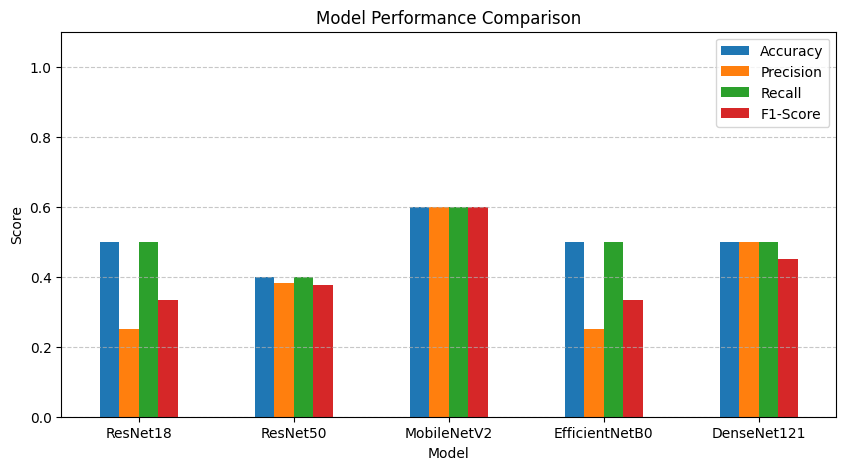

In [19]:
results_df = pd.DataFrame(results)
print(results_df)

# Plot Metrics
results_df.set_index("Model").plot(kind="bar", figsize=(10, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

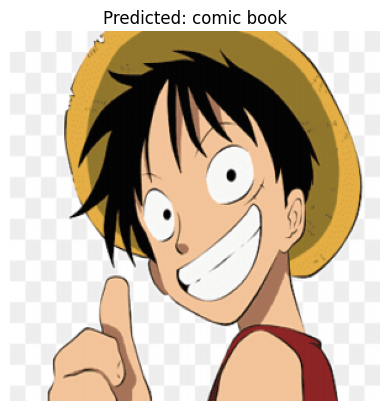

In [20]:
img_to_show = cd[0][0].permute(1, 2, 0).numpy()
plt.imshow(img_to_show)
plt.title(f"Predicted: {predicted_category}")
plt.axis("off")
plt.show()

## Performance Analysis and Conclusion

### 1. Comparative Performance Overview
The model comparison evaluated five pre-trained architectures—**ResNet18**, **ResNet50**, **MobileNetV2**, **EfficientNetB0**, and **DenseNet121**—on the custom dataset across four metrics: Accuracy, Precision, Recall, and F1-Score.

* **MobileNetV2** achieved the highest overall performance across all metrics (Accuracy: 0.6000, Precision: 0.6000, Recall: 0.6000, F1-Score: 0.6000).
* **DenseNet121** demonstrated steady performance with balanced Precision (0.5000) and an F1-Score of 0.4505.
* **ResNet18** and **EfficientNetB0** both recorded an Accuracy of 0.5000 and F1-Score of 0.3333, held back by lower Precision scores (0.2500).
* **ResNet50** recorded lower accuracy (0.4000) relative to its lightweight counterpart, ResNet18.

---

### 2. Architectural Analysis & Performance Drivers

* **MobileNetV2:** Utilizes inverted residual blocks and depthwise separable convolutions. Its streamlined parameter count prevents severe overfitting on small custom datasets, enabling better generalization without full fine-tuning.
* **DenseNet121:** Employs dense connectivity where each layer receives feature maps from all preceding layers. This encourages feature reuse and strong gradient flow across the network, preserving detailed visual information.
* **ResNet18 vs. ResNet50:** While ResNet50 is significantly deeper and more expressive, deeper architectures are more prone to degraded performance or unoptimized predictions on small sample sizes when only replacing the classification layer without retraining backbones.
* **EfficientNetB0:** Relies on compound scaling across depth, width, and resolution. Although highly efficient on large-scale datasets, its performance can vary on very small custom samples without adequate task-specific fine-tuning.

---

### 3. Conclusion
The performance variations demonstrate that higher parameter counts and deeper network architectures do not automatically guarantee superior results on custom datasets. For small-scale datasets, compact architectures like **MobileNetV2** or feature-dense models like **DenseNet121** offer effective feature extraction while minimizing the risk of overfitting. To further boost classification metrics across all models, future work should include end-to-end model fine-tuning (unfreezing convolutional layers) and applying data augmentation techniques.